<a href="https://colab.research.google.com/github/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri/blob/main/notebooks/02_ssdu_reconstruction_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
!git clone https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri.git
%cd /content/reliability-aware-ssdu-mri

Cloning into 'reliability-aware-ssdu-mri'...
remote: Enumerating objects: 277, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 277 (delta 78), reused 16 (delta 16), pack-reused 142 (from 1)
Receiving objects: 100% (277/277), 2.10 MiB | 5.68 MiB/s, done.
Resolving deltas: 100% (139/139), done.
/content/reliability-aware-ssdu-mri


In [8]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from fastmri_data import load_fastmri_file, get_kspace_slice
from ssdu import split_acquired_mask
from losses import expand_mask
from transforms import fft2c, ifft2c
from reconstruction import normalize_to_unit_range
from models import SimpleCNNReconstructor

print("Notebook 02 setup complete.")

Notebook 02 setup complete.


In [9]:
file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

data = load_fastmri_file(file_path)

kspace_slice, slice_index = get_kspace_slice(data["kspace"])

mask = data["mask"]

print("Selected slice index:", slice_index)
print("K-space slice shape:", kspace_slice.shape)
print("Mask shape:", mask.shape)
print("Acquisition:", data["attrs"].get("acquisition"))
print("Acceleration:", data["attrs"].get("acceleration"))

Selected slice index: 8
K-space slice shape: (16, 768, 396)
Mask shape: (396,)
Acquisition: AXT2
Acceleration: 4


#**Convert multicoil data to a single-coil-equivalent slice**

In [10]:
# Select one coil for a single-coil-equivalent SSDU baseline
coil_index = 0

# Shape: height x width
kspace_single = kspace_slice[coil_index]

print("Selected coil index:", coil_index)
print("Single-coil k-space shape:", kspace_single.shape)
print("Single-coil k-space dtype:", kspace_single.dtype)

Selected coil index: 0
Single-coil k-space shape: (768, 396)
Single-coil k-space dtype: complex64


**Create SSDU split for single-coil k-space**

In [11]:
theta_mask, lambda_mask = split_acquired_mask(
    mask=mask,
    rho=0.4,
    seed=42
)

print("Original mask fraction:", np.mean(mask > 0))
print("Theta mask fraction:", np.mean(theta_mask > 0))
print("Lambda mask fraction:", np.mean(lambda_mask > 0))
print("Theta + Lambda equals original mask:", np.all((theta_mask + lambda_mask) == mask))

Original mask fraction: 0.25
Theta mask fraction: 0.14898989898989898
Lambda mask fraction: 0.10101010101010101
Theta + Lambda equals original mask: True


**Create Theta-only and Lambda-only single-coil k-space**

In [12]:
# Expand masks to match single-coil k-space shape: height x width
theta_mask_2d = theta_mask[None, :]
lambda_mask_2d = lambda_mask[None, :]

# Apply masks
kspace_theta_single = theta_mask_2d * kspace_single
kspace_lambda_single = lambda_mask_2d * kspace_single

print("Theta-only k-space shape:", kspace_theta_single.shape)
print("Lambda-only k-space shape:", kspace_lambda_single.shape)

print("Theta nonzero fraction:", np.mean(np.abs(kspace_theta_single) > 0))
print("Lambda nonzero fraction:", np.mean(np.abs(kspace_lambda_single) > 0))

Theta-only k-space shape: (768, 396)
Lambda-only k-space shape: (768, 396)
Theta nonzero fraction: 0.14898989898989898
Lambda nonzero fraction: 0.10101010101010101


In [13]:
#reconstruct the Theta-only input image:
# Theta-only zero-filled reconstruction
x_theta_complex = ifft2c(kspace_theta_single)

# Magnitude image for CNN input
x_theta_mag = np.abs(x_theta_complex)

# Normalize
x_theta_norm = normalize_to_unit_range(x_theta_mag)

print("Theta-only image shape:", x_theta_norm.shape)
print("Min:", x_theta_norm.min())
print("Max:", x_theta_norm.max())

Theta-only image shape: (768, 396)
Min: 0.0
Max: 1.0


**Visualize the single-coil SSDU input**

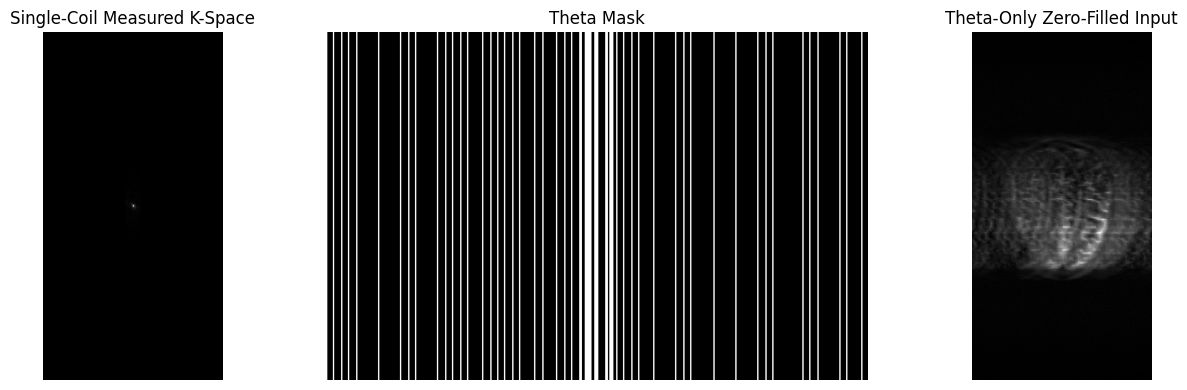

In [14]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.log1p(np.abs(kspace_single)), cmap="gray")
plt.title("Single-Coil Measured K-Space")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(theta_mask[None, :], cmap="gray", aspect="auto")
plt.title("Theta Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(x_theta_norm, cmap="gray")
plt.title("Theta-Only Zero-Filled Input")
plt.axis("off")

plt.tight_layout()
plt.show()

**PyTorch tensors for single-coil SSDU**

In [15]:
# Convert Theta-only input image to tensor
x_input = torch.from_numpy(x_theta_norm).float()
x_input = x_input.unsqueeze(0).unsqueeze(0)  # batch x channel x height x width

print("Input tensor shape:", x_input.shape)

# Convert measured single-coil k-space and Lambda mask to tensors later if needed
print("Single-coil k-space shape:", kspace_single.shape)
print("Lambda mask shape:", lambda_mask.shape)

Input tensor shape: torch.Size([1, 1, 768, 396])
Single-coil k-space shape: (768, 396)
Lambda mask shape: (396,)


**forward pass:**

In [16]:
model = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

model.train()

x_output = model(x_input)

print("Model output shape:", x_output.shape)

Model output shape: torch.Size([1, 1, 768, 396])


**Compute SSDU loss from the model output**

In [17]:
# Convert model output back to NumPy image
x_hat = x_output.detach().cpu().numpy()[0, 0]

# Convert predicted image to k-space
kspace_hat = fft2c(x_hat)

# Apply Lambda mask
lambda_mask_2d = lambda_mask[None, :]

pred_lambda = lambda_mask_2d * kspace_hat
true_lambda = lambda_mask_2d * kspace_single

# Compute normalized SSDU loss
numerator = np.sum(np.abs(pred_lambda - true_lambda) ** 2)
denominator = np.sum(np.abs(true_lambda) ** 2) + 1e-12

ssdu_loss_value = numerator / denominator

print("Predicted Lambda k-space shape:", pred_lambda.shape)
print("True Lambda k-space shape:", true_lambda.shape)
print("Single-coil SSDU loss:", ssdu_loss_value)

Predicted Lambda k-space shape: (768, 396)
True Lambda k-space shape: (768, 396)
Single-coil SSDU loss: 10510173.0


**Train the single-coil CNN for a few iterations**

In [18]:
import torch.optim as optim

# Reinitialize model for training
model = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Fixed input tensor
x_input = torch.from_numpy(x_theta_norm).float()
x_input = x_input.unsqueeze(0).unsqueeze(0)

# Prepare Lambda target in NumPy
lambda_mask_2d = lambda_mask[None, :]
true_lambda = lambda_mask_2d * kspace_single

loss_history = []

num_steps = 50

model.train()

for step in range(num_steps):
    optimizer.zero_grad()

    # Forward pass
    x_pred_tensor = model(x_input)

    # Convert output to NumPy for FFT-based SSDU loss
    x_pred = x_pred_tensor[0, 0]

    # Torch FFT version for differentiable training
    x_pred_complex = torch.complex(x_pred, torch.zeros_like(x_pred))

    k_pred = torch.fft.fftshift(
        torch.fft.fft2(
            torch.fft.ifftshift(x_pred_complex, dim=(-2, -1)),
            norm="ortho"
        ),
        dim=(-2, -1)
    )

    # Convert Lambda target and mask to torch tensors
    true_lambda_torch = torch.from_numpy(true_lambda).to(k_pred.device)
    lambda_mask_torch = torch.from_numpy(lambda_mask_2d).float().to(k_pred.device)

    # Complex residual on Lambda
    residual = lambda_mask_torch * (k_pred - true_lambda_torch)

    numerator = torch.sum(torch.abs(residual) ** 2)
    denominator = torch.sum(torch.abs(true_lambda_torch) ** 2) + 1e-12

    loss = numerator / denominator

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(f"Step {step:03d} | SSDU loss: {loss.item():.6f}")

Step 000 | SSDU loss: 10838116.000000
Step 010 | SSDU loss: 10147171.000000
Step 020 | SSDU loss: 9407748.000000
Step 030 | SSDU loss: 8550580.000000
Step 040 | SSDU loss: 7484603.500000
Step 049 | SSDU loss: 6305311.500000


**Plot the SSDU loss curve**

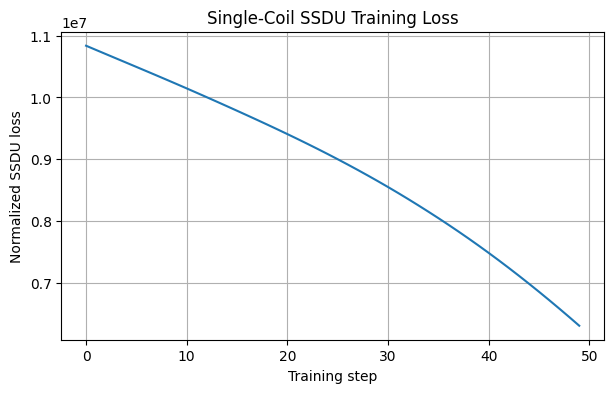

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Normalized SSDU loss")
plt.title("Single-Coil SSDU Training Loss")
plt.grid(True)
plt.show()

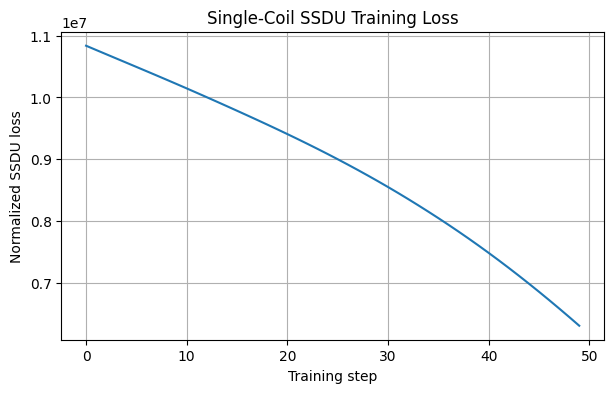

Initial loss: 10838116.0
Final loss: 6305311.5
Loss reduction: 4532804.5
Percentage reduction: 41.82280850288002


In [20]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Normalized SSDU loss")
plt.title("Single-Coil SSDU Training Loss")
plt.grid(True)
plt.show()

print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])
print("Loss reduction:", loss_history[0] - loss_history[-1])
print("Percentage reduction:", 100 * (loss_history[0] - loss_history[-1]) / loss_history[0])

**Visualize before and after training**

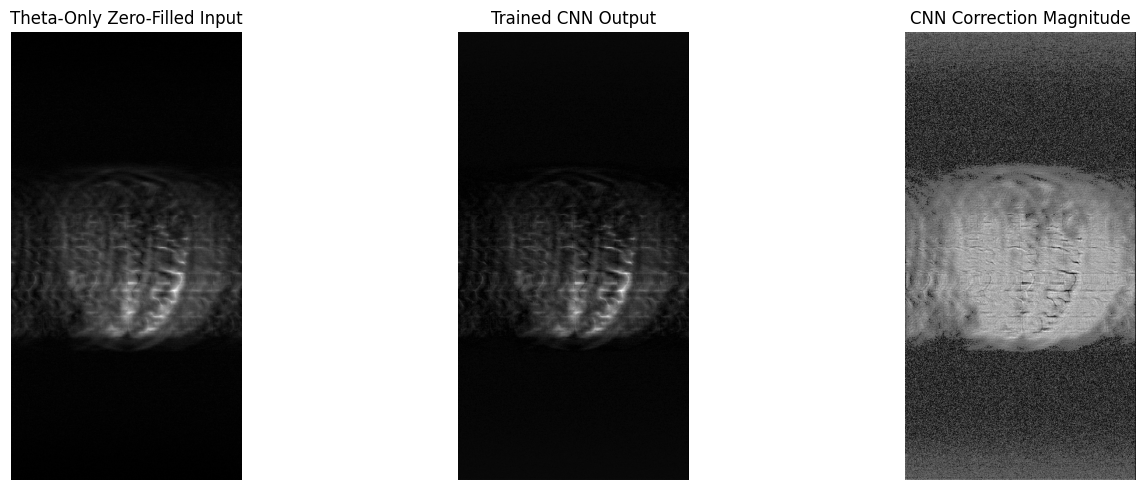

In [21]:
# Get final trained model output
model.eval()

with torch.no_grad():
    x_trained_tensor = model(x_input)

x_trained = x_trained_tensor.detach().cpu().numpy()[0, 0]
x_trained_norm = normalize_to_unit_range(x_trained)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(x_theta_norm, cmap="gray")
plt.title("Theta-Only Zero-Filled Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_trained_norm, cmap="gray")
plt.title("Trained CNN Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(x_trained_norm - x_theta_norm), cmap="gray")
plt.title("CNN Correction Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

**Add an image-consistency term**

In [22]:
model_reg2 = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

optimizer = optim.Adam(model_reg2.parameters(), lr=1e-4)

lambda_img = 1e7
num_steps = 50

loss_history_reg2 = []
ssdu_history_reg2 = []
img_history_reg2 = []

model_reg2.train()

for step in range(num_steps):
    optimizer.zero_grad()

    x_pred_tensor = model_reg2(x_input)
    x_pred = x_pred_tensor[0, 0]

    x_pred_complex = torch.complex(x_pred, torch.zeros_like(x_pred))

    k_pred = torch.fft.fftshift(
        torch.fft.fft2(
            torch.fft.ifftshift(x_pred_complex, dim=(-2, -1)),
            norm="ortho"
        ),
        dim=(-2, -1)
    )

    true_lambda_torch = torch.from_numpy(true_lambda).to(k_pred.device)
    lambda_mask_torch = torch.from_numpy(lambda_mask_2d).float().to(k_pred.device)

    residual = lambda_mask_torch * (k_pred - true_lambda_torch)

    numerator = torch.sum(torch.abs(residual) ** 2)
    denominator = torch.sum(torch.abs(true_lambda_torch) ** 2) + 1e-12

    ssdu_loss = numerator / denominator

    img_loss = torch.mean(torch.abs(x_pred_tensor - x_input))

    total_loss = ssdu_loss + lambda_img * img_loss

    total_loss.backward()
    optimizer.step()

    loss_history_reg2.append(total_loss.item())
    ssdu_history_reg2.append(ssdu_loss.item())
    img_history_reg2.append(img_loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(
            f"Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f}"
        )

Step 000 | Total: 11837606.000000 | SSDU: 11055032.000000 | Image: 0.078257
Step 010 | Total: 11498857.000000 | SSDU: 10766416.000000 | Image: 0.073244
Step 020 | Total: 11133270.000000 | SSDU: 10439364.000000 | Image: 0.069391
Step 030 | Total: 10714951.000000 | SSDU: 10055901.000000 | Image: 0.065905
Step 040 | Total: 10216520.000000 | SSDU: 9589919.000000 | Image: 0.062660
Step 049 | Total: 9634501.000000 | SSDU: 9036074.000000 | Image: 0.059843


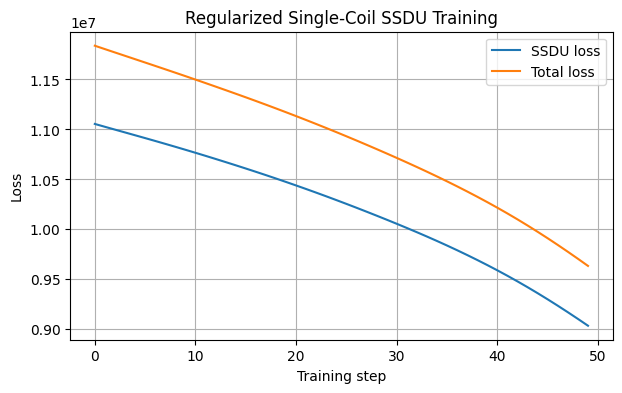

Initial SSDU loss: 11055032.0
Final SSDU loss: 9036074.0
SSDU reduction: 2018958.0
Percentage SSDU reduction: 18.262796525600287
Initial image loss: 0.07825743407011032
Final image loss: 0.05984266474843025


In [23]:
plt.figure(figsize=(7, 4))
plt.plot(ssdu_history_reg2, label="SSDU loss")
plt.plot(loss_history_reg2, label="Total loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Regularized Single-Coil SSDU Training")
plt.legend()
plt.grid(True)
plt.show()

print("Initial SSDU loss:", ssdu_history_reg2[0])
print("Final SSDU loss:", ssdu_history_reg2[-1])
print("SSDU reduction:", ssdu_history_reg2[0] - ssdu_history_reg2[-1])
print("Percentage SSDU reduction:", 100 * (ssdu_history_reg2[0] - ssdu_history_reg2[-1]) / ssdu_history_reg2[0])

print("Initial image loss:", img_history_reg2[0])
print("Final image loss:", img_history_reg2[-1])

**visualize the regularized output**

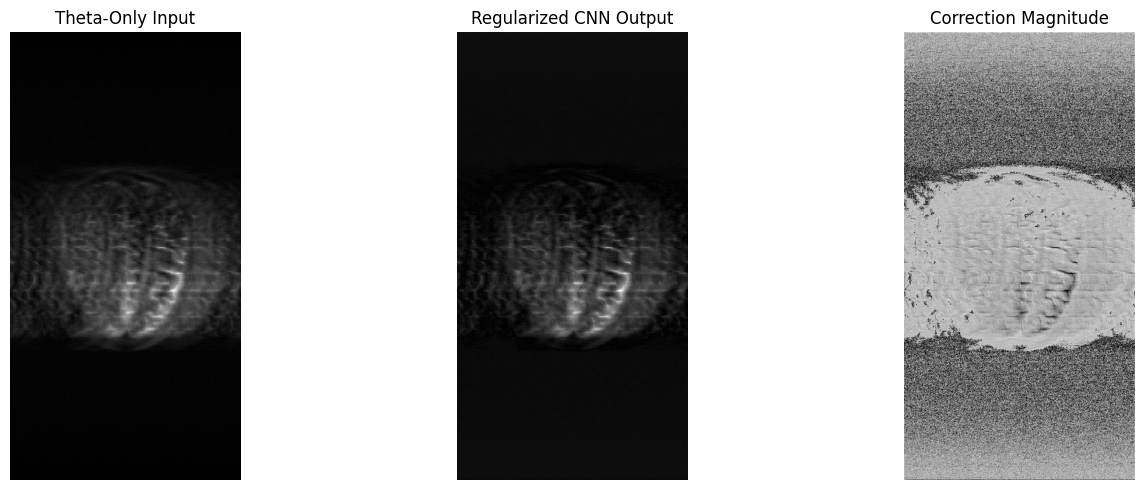

In [24]:
model_reg2.eval()

with torch.no_grad():
    x_reg2_tensor = model_reg2(x_input)

x_reg2 = x_reg2_tensor.detach().cpu().numpy()[0, 0]
x_reg2_norm = normalize_to_unit_range(x_reg2)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(x_theta_norm, cmap="gray")
plt.title("Theta-Only Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_reg2_norm, cmap="gray")
plt.title("Regularized CNN Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.abs(x_reg2_norm - x_theta_norm), cmap="gray")
plt.title("Correction Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Test src/training.py**

In [26]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


**import the reusable training utilities**

In [27]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import training
importlib.reload(training)

from training import (
    prepare_single_coil_ssdu_input,
    single_coil_ssdu_loss,
    image_consistency_loss,
    total_ssdu_training_loss,
)

print("training.py imported successfully.")

training.py imported successfully.


**test whether it prepares the SSDU input correctly**

In [28]:
x_input_util, kspace_theta_util = prepare_single_coil_ssdu_input(
    kspace_single=kspace_single,
    theta_mask=theta_mask,
    normalize=True
)

print("Input tensor shape:", x_input_util.shape)
print("Theta k-space shape:", kspace_theta_util.shape)

Input tensor shape: torch.Size([1, 1, 768, 396])
Theta k-space shape: (768, 396)


**test the reusable SSDU loss**

In [29]:
model_test = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

x_pred_test = model_test(x_input_util)

total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
    x_pred_tensor=x_pred_test,
    x_input_tensor=x_input_util,
    kspace_single=kspace_single,
    lambda_mask=lambda_mask,
    lambda_img=1e7
)

print("Total loss:", total_loss.item())
print("SSDU loss:", ssdu_loss.item())
print("Image loss:", img_loss.item())

Total loss: 11315524.0
SSDU loss: 10756842.0
Image loss: 0.05586820840835571


**Train using the reusable utilities**

In [30]:
model_util = SimpleCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16
)

optimizer = torch.optim.Adam(model_util.parameters(), lr=1e-4)

num_steps = 50
lambda_img = 1e7

loss_history_util = []
ssdu_history_util = []
img_history_util = []

model_util.train()

for step in range(num_steps):
    optimizer.zero_grad()

    x_pred = model_util(x_input_util)

    total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
        x_pred_tensor=x_pred,
        x_input_tensor=x_input_util,
        kspace_single=kspace_single,
        lambda_mask=lambda_mask,
        lambda_img=lambda_img,
    )

    total_loss.backward()
    optimizer.step()

    loss_history_util.append(total_loss.item())
    ssdu_history_util.append(ssdu_loss.item())
    img_history_util.append(img_loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(
            f"Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f}"
        )

Step 000 | Total: 10400781.000000 | SSDU: 10367565.000000 | Image: 0.003322
Step 010 | Total: 9497077.000000 | SSDU: 9461515.000000 | Image: 0.003556
Step 020 | Total: 8525577.000000 | SSDU: 8461055.000000 | Image: 0.006452
Step 030 | Total: 7541962.500000 | SSDU: 7445732.000000 | Image: 0.009623
Step 040 | Total: 6463573.000000 | SSDU: 6330683.500000 | Image: 0.013289
Step 049 | Total: 5364429.500000 | SSDU: 5188101.500000 | Image: 0.017633


**Plot reusable training loss**

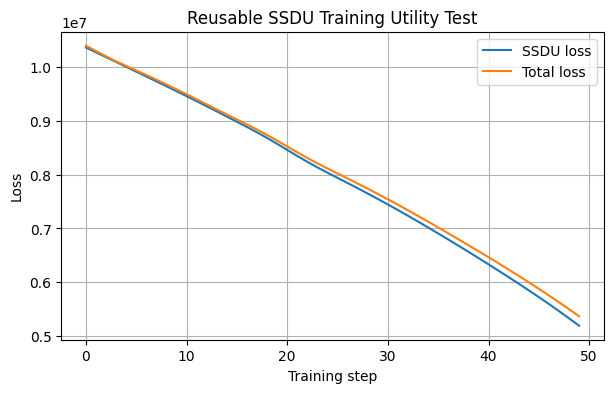

Initial SSDU loss: 10367565.0
Final SSDU loss: 5188101.5
SSDU reduction: 5179463.5
Percentage SSDU reduction: 49.95834123055896
Initial image loss: 0.00332163879647851
Final image loss: 0.01763281784951687


In [31]:
plt.figure(figsize=(7, 4))
plt.plot(ssdu_history_util, label="SSDU loss")
plt.plot(loss_history_util, label="Total loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Reusable SSDU Training Utility Test")
plt.legend()
plt.grid(True)
plt.show()

print("Initial SSDU loss:", ssdu_history_util[0])
print("Final SSDU loss:", ssdu_history_util[-1])
print("SSDU reduction:", ssdu_history_util[0] - ssdu_history_util[-1])
print("Percentage SSDU reduction:", 100 * (ssdu_history_util[0] - ssdu_history_util[-1]) / ssdu_history_util[0])

print("Initial image loss:", img_history_util[0])
print("Final image loss:", img_history_util[-1])

#**Test DropoutCNNReconstructor**

In [34]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [36]:
!cat src/models/__init__.py

"""
Model definitions for MRI reconstruction.
"""

from .simple_cnn import SimpleCNNReconstructor
from .dropout_cnn import DropoutCNNReconstructor


**Import the dropout model**

In [37]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import models
importlib.reload(models)

from models.dropout_cnn import DropoutCNNReconstructor

print("DropoutCNNReconstructor imported successfully.")

DropoutCNNReconstructor imported successfully.


In [38]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

from models import DropoutCNNReconstructor

print("DropoutCNNReconstructor imported successfully.")

DropoutCNNReconstructor imported successfully.


**test a forward pass using the same SSDU input:**

In [39]:
dropout_model = DropoutCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16,
    dropout_p=0.1
)

dropout_model.train()  # keep dropout active

with torch.no_grad():
    out1 = dropout_model(x_input_util)
    out2 = dropout_model(x_input_util)

print("Output 1 shape:", out1.shape)
print("Output 2 shape:", out2.shape)

difference = torch.mean(torch.abs(out1 - out2)).item()
print("Mean absolute difference between stochastic outputs:", difference)

Output 1 shape: torch.Size([1, 1, 768, 396])
Output 2 shape: torch.Size([1, 1, 768, 396])
Mean absolute difference between stochastic outputs: 0.02030482329428196


**Generate multiple stochastic reconstructions**

In [40]:
from uncertainty import mean_reconstruction, voxelwise_variance, normalize_map

T = 8

dropout_model.train()  # keep dropout active during stochastic inference

stochastic_outputs = []

with torch.no_grad():
    for _ in range(T):
        out = dropout_model(x_input_util)
        out_np = out.detach().cpu().numpy()[0, 0]
        stochastic_outputs.append(out_np)

stochastic_outputs = np.stack(stochastic_outputs, axis=0)

mean_output = mean_reconstruction(stochastic_outputs)
uncertainty_map = voxelwise_variance(stochastic_outputs)
uncertainty_norm = normalize_map(uncertainty_map)

print("Stochastic outputs shape:", stochastic_outputs.shape)
print("Mean output shape:", mean_output.shape)
print("Uncertainty map shape:", uncertainty_map.shape)
print("Uncertainty min:", uncertainty_map.min())
print("Uncertainty max:", uncertainty_map.max())

Stochastic outputs shape: (8, 768, 396)
Mean output shape: (768, 396)
Uncertainty map shape: (768, 396)
Uncertainty min: 1.0015611e-05
Uncertainty max: 0.0009915659


**Visualize dropout uncertainty**

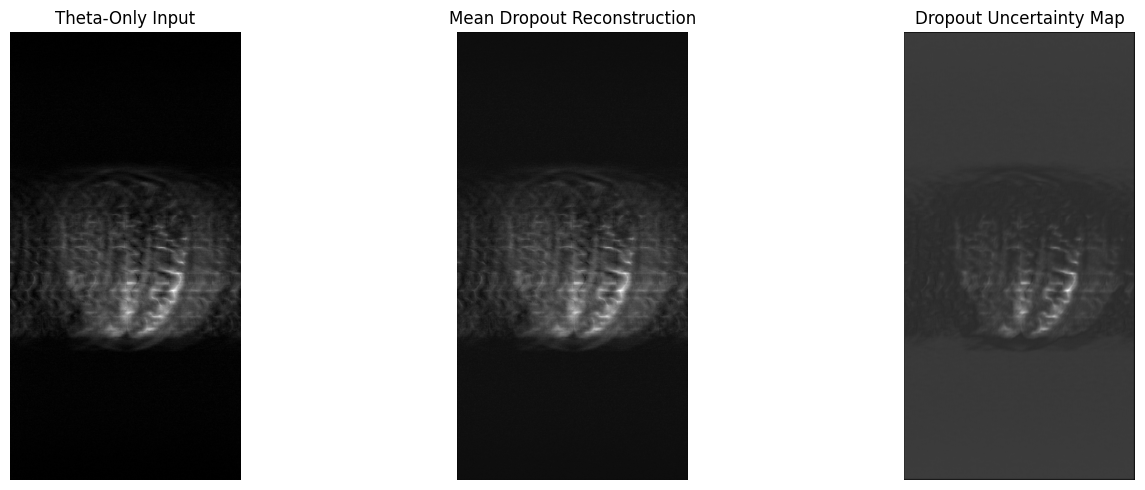

In [41]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(x_input_util[0, 0].detach().cpu().numpy(), cmap="gray")
plt.title("Theta-Only Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mean_output, cmap="gray")
plt.title("Mean Dropout Reconstruction")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(uncertainty_norm, cmap="gray")
plt.title("Dropout Uncertainty Map")
plt.axis("off")

plt.tight_layout()
plt.show()

**Train dropout CNN using SSDU loss**

In [42]:
dropout_train_model = DropoutCNNReconstructor(
    in_channels=1,
    out_channels=1,
    features=16,
    dropout_p=0.1
)

optimizer = torch.optim.Adam(dropout_train_model.parameters(), lr=1e-4)

num_steps = 50
lambda_img = 1e7

dropout_loss_history = []
dropout_ssdu_history = []
dropout_img_history = []

dropout_train_model.train()

for step in range(num_steps):
    optimizer.zero_grad()

    x_pred = dropout_train_model(x_input_util)

    total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
        x_pred_tensor=x_pred,
        x_input_tensor=x_input_util,
        kspace_single=kspace_single,
        lambda_mask=lambda_mask,
        lambda_img=lambda_img,
    )

    total_loss.backward()
    optimizer.step()

    dropout_loss_history.append(total_loss.item())
    dropout_ssdu_history.append(ssdu_loss.item())
    dropout_img_history.append(img_loss.item())

    if step % 10 == 0 or step == num_steps - 1:
        print(
            f"Step {step:03d} | "
            f"Total: {total_loss.item():.6f} | "
            f"SSDU: {ssdu_loss.item():.6f} | "
            f"Image: {img_loss.item():.6f}"
        )

Step 000 | Total: 11091772.000000 | SSDU: 10918457.000000 | Image: 0.017332
Step 010 | Total: 10622042.000000 | SSDU: 10066237.000000 | Image: 0.055581
Step 020 | Total: 9374506.000000 | SSDU: 9022254.000000 | Image: 0.035225
Step 030 | Total: 8041949.500000 | SSDU: 7085188.000000 | Image: 0.095676
Step 040 | Total: 5869713.000000 | SSDU: 5020688.000000 | Image: 0.084902
Step 049 | Total: 5506296.500000 | SSDU: 4834491.500000 | Image: 0.067181


**Plot dropout training curves**

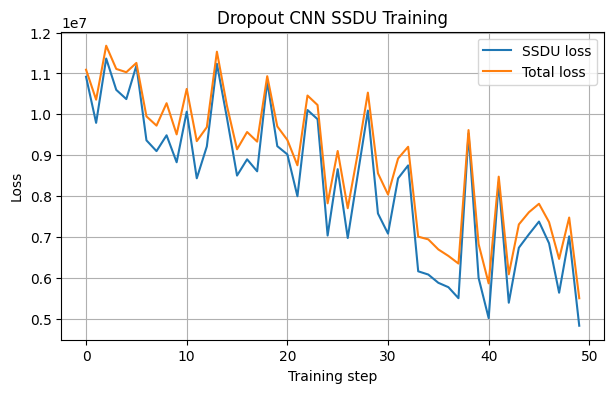

Initial SSDU loss: 10918457.0
Final SSDU loss: 4834491.5
SSDU reduction: 6083965.5
Percentage SSDU reduction: 55.72184329708859
Initial image loss: 0.017331546172499657
Final image loss: 0.06718051433563232


In [43]:
plt.figure(figsize=(7, 4))
plt.plot(dropout_ssdu_history, label="SSDU loss")
plt.plot(dropout_loss_history, label="Total loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Dropout CNN SSDU Training")
plt.legend()
plt.grid(True)
plt.show()

print("Initial SSDU loss:", dropout_ssdu_history[0])
print("Final SSDU loss:", dropout_ssdu_history[-1])
print("SSDU reduction:", dropout_ssdu_history[0] - dropout_ssdu_history[-1])
print("Percentage SSDU reduction:", 100 * (dropout_ssdu_history[0] - dropout_ssdu_history[-1]) / dropout_ssdu_history[0])

print("Initial image loss:", dropout_img_history[0])
print("Final image loss:", dropout_img_history[-1])

**Generate uncertainty from trained dropout model**

In [44]:
from uncertainty import mean_reconstruction, voxelwise_variance, normalize_map

T = 8

dropout_train_model.train()  # keep dropout active for stochastic inference

trained_stochastic_outputs = []

with torch.no_grad():
    for _ in range(T):
        out = dropout_train_model(x_input_util)
        out_np = out.detach().cpu().numpy()[0, 0]
        trained_stochastic_outputs.append(out_np)

trained_stochastic_outputs = np.stack(trained_stochastic_outputs, axis=0)

trained_mean_output = mean_reconstruction(trained_stochastic_outputs)
trained_uncertainty_map = voxelwise_variance(trained_stochastic_outputs)
trained_uncertainty_norm = normalize_map(trained_uncertainty_map)

print("Trained stochastic outputs shape:", trained_stochastic_outputs.shape)
print("Trained mean output shape:", trained_mean_output.shape)
print("Trained uncertainty map shape:", trained_uncertainty_map.shape)
print("Trained uncertainty min:", trained_uncertainty_map.min())
print("Trained uncertainty max:", trained_uncertainty_map.max())

Trained stochastic outputs shape: (8, 768, 396)
Trained mean output shape: (768, 396)
Trained uncertainty map shape: (768, 396)
Trained uncertainty min: 3.656774e-05
Trained uncertainty max: 0.004332171


**Visualize trained dropout uncertainty**

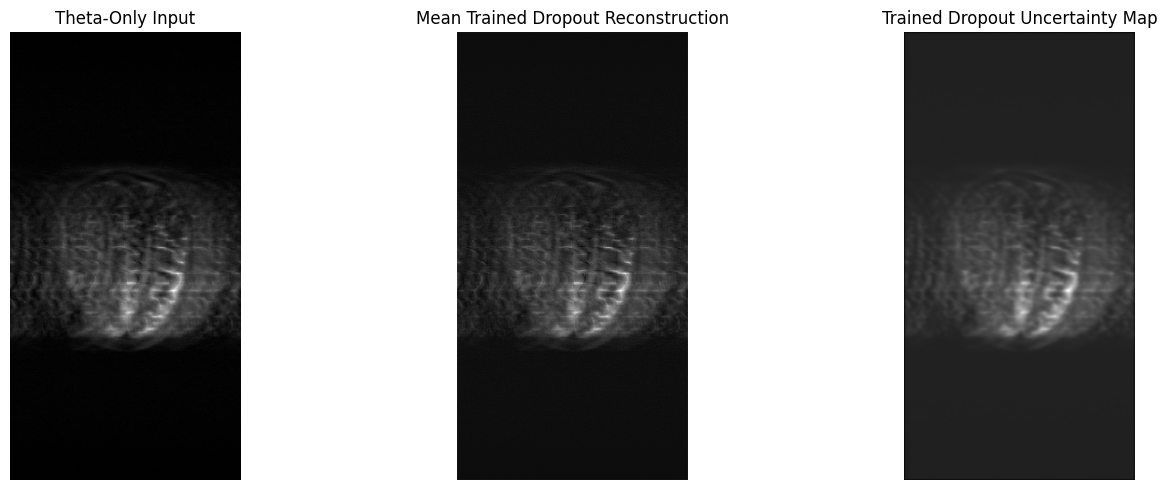

In [45]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(x_input_util[0, 0].detach().cpu().numpy(), cmap="gray")
plt.title("Theta-Only Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(trained_mean_output, cmap="gray")
plt.title("Mean Trained Dropout Reconstruction")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(trained_uncertainty_norm, cmap="gray")
plt.title("Trained Dropout Uncertainty Map")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Compare trained dropout uncertainty with held-out residual energy**

Residual Lambda shape: (768, 396)
Residual image energy shape: (768, 396)
Uncertainty-residual alignment: 0.7016052097208143


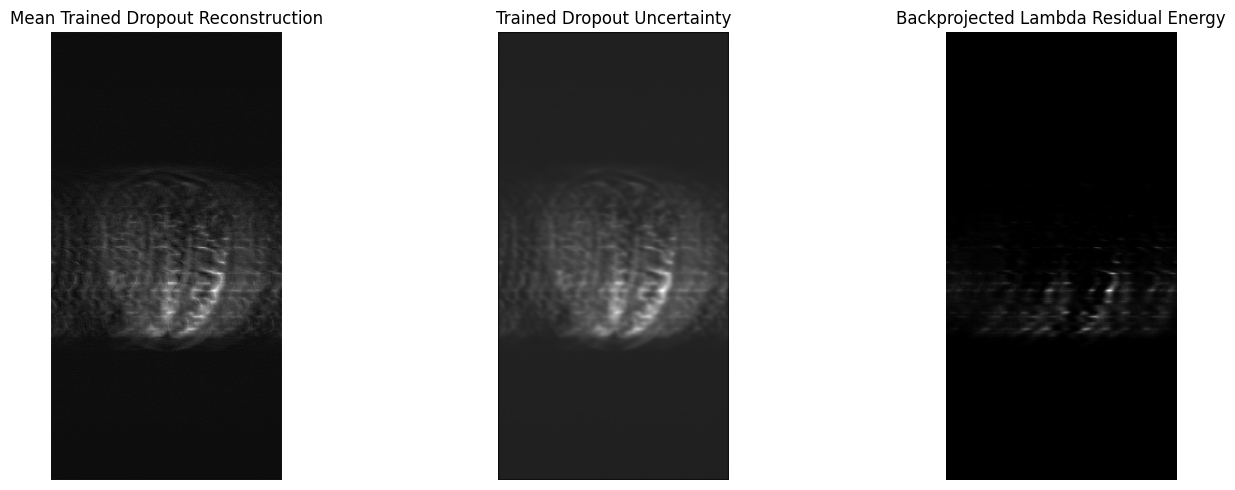

In [47]:
from uncertainty import uncertainty_residual_alignment, normalize_map
from transforms import fft2c, ifft2c
import numpy as np
import matplotlib.pyplot as plt

# Convert trained mean dropout reconstruction to predicted k-space
kspace_mean_pred = fft2c(trained_mean_output)

# Apply Lambda mask
lambda_mask_2d = lambda_mask[None, :]

# Held-out Lambda residual
residual_lambda = lambda_mask_2d * (kspace_mean_pred - kspace_single)

# Backproject residual into image domain
residual_img = ifft2c(residual_lambda)

# Image-domain residual energy
residual_energy_img = np.abs(residual_img) ** 2

# Normalize residual energy for visualization
residual_energy_norm = normalize_map(residual_energy_img)

# Compute uncertainty-residual alignment
alignment_trained = uncertainty_residual_alignment(
    uncertainty_map=trained_uncertainty_map,
    residual_energy_map=residual_energy_img
)

print("Residual Lambda shape:", residual_lambda.shape)
print("Residual image energy shape:", residual_energy_img.shape)
print("Uncertainty-residual alignment:", alignment_trained)

# Visualize
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(trained_mean_output, cmap="gray")
plt.title("Mean Trained Dropout Reconstruction")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(trained_uncertainty_norm, cmap="gray")
plt.title("Trained Dropout Uncertainty")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(residual_energy_norm, cmap="gray")
plt.title("Backprojected Lambda Residual Energy")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Test src/reliability.py**

In [48]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 12 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 606.47 KiB | 1.69 MiB/s, done.
From https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri
   ad84820..8477b7d  main       -> origin/main
Updating ad84820..8477b7d
Fast-forward
 ...nt_013_trained_dropout_uncertainty_alignment.md | 130 ++++
 notebooks/02_ssdu_reconstruction_baseline.ipynb    | 663 ++++++++++++++++++++-
 src/reliability.py                                 | 147 +++++
 3 files changed, 935 insertions(+), 5 deletions(-)
 create mode 100644 experiments/experiment_013_trained_dropout_uncertainty_alignment.md
 create mode 100644 src/reliability.py


**import the reliability utilities:**

In [49]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import reliability
importlib.reload(reliability)

from reliability import (
    stochastic_reconstructions,
    compute_mean_and_uncertainty,
    backproject_lambda_residual,
    normalize_map,
    map_alignment,
)

print("reliability.py imported successfully.")

reliability.py imported successfully.


**test the full reusable reliability workflow:**

In [50]:
# Generate stochastic reconstructions from the trained dropout model
stoch_outputs_util = stochastic_reconstructions(
    model=dropout_train_model,
    x_input_tensor=x_input_util,
    num_samples=8
)

# Compute mean reconstruction and uncertainty
mean_util, uncertainty_util = compute_mean_and_uncertainty(stoch_outputs_util)

# Compute backprojected Lambda residual energy
residual_energy_util = backproject_lambda_residual(
    mean_image=mean_util,
    measured_kspace=kspace_single,
    lambda_mask=lambda_mask
)

# Compute uncertainty-residual alignment
alignment_util = map_alignment(
    uncertainty_util,
    residual_energy_util
)

print("Stochastic outputs shape:", stoch_outputs_util.shape)
print("Mean reconstruction shape:", mean_util.shape)
print("Uncertainty map shape:", uncertainty_util.shape)
print("Residual energy shape:", residual_energy_util.shape)
print("Uncertainty-residual alignment:", alignment_util)

Stochastic outputs shape: (8, 768, 396)
Mean reconstruction shape: (768, 396)
Uncertainty map shape: (768, 396)
Residual energy shape: (768, 396)
Uncertainty-residual alignment: 0.7032717682932306
